In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('C:/Users/Dell/Downloads/ML-Capstone-Projects/Beginner-Projects/Project-4/code/winequality-red.csv')

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
df['quality'].unique()

array([5, 6, 7, 4, 8, 3])

In [5]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(240)

In [7]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [8]:
df.shape #rows and column

(1599, 12)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

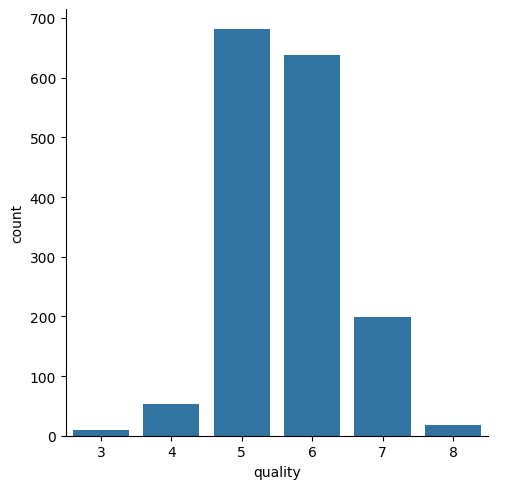

In [10]:
sns.catplot(x='quality',data=df,kind='count')

<Axes: xlabel='quality', ylabel='volatile acidity'>

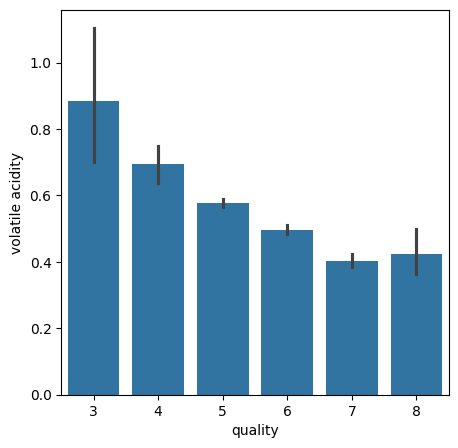

In [11]:
#volatile acidity vs quality
plot=plt.figure(figsize=(5,5))
sns.barplot(x='quality',y='volatile acidity',data=df)

<Axes: xlabel='quality', ylabel='citric acid'>

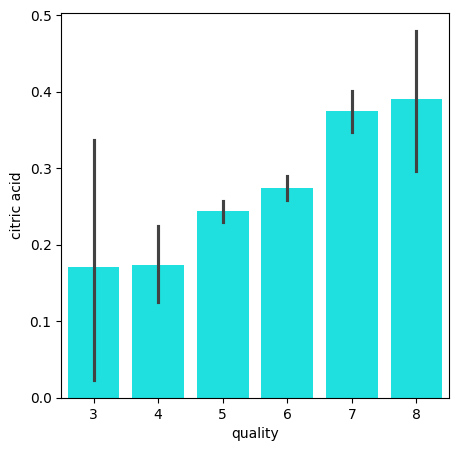

In [12]:
#citric acid vs quality
plot=plt.figure(figsize=(5,5))
sns.barplot(x='quality',y='citric acid',data=df,color='cyan')

In [13]:
correlation=df.corr()

<Axes: >

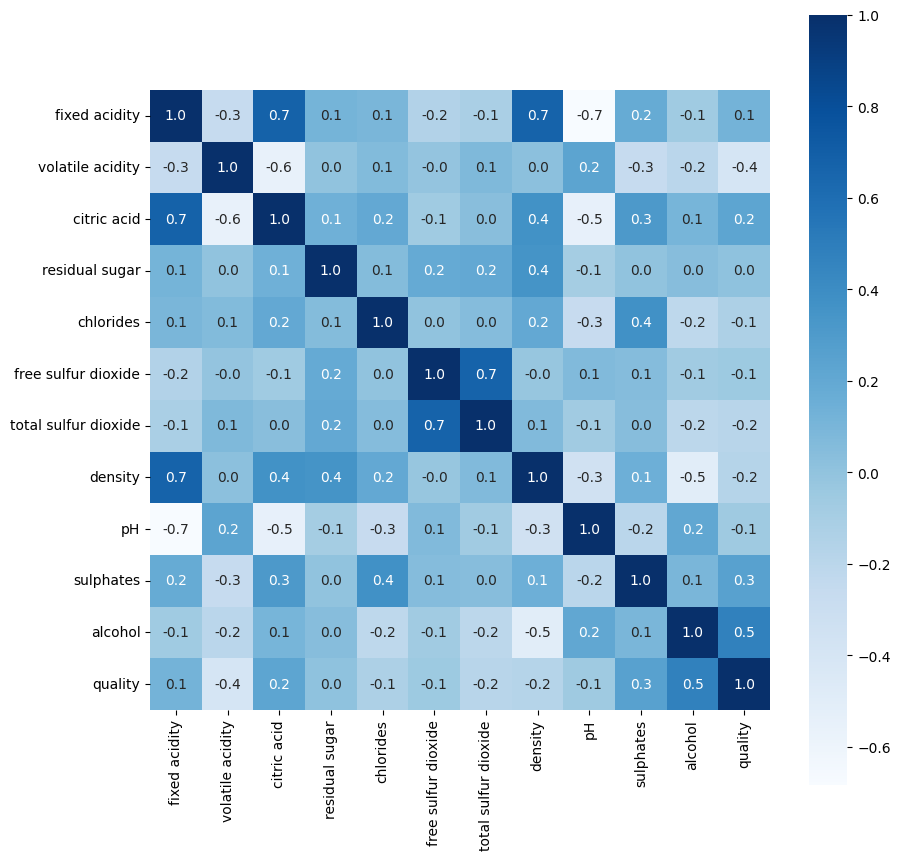

In [14]:
plt.figure(figsize=(10,10))
sns.heatmap(correlation,annot=True,cbar=True,square=True,cmap='Blues',annot_kws={'size':10},fmt='.1f')

In [15]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [16]:
X=df.drop(columns=['quality'])
Y=df['quality']


In [17]:
#Label Binarization1
Y=df['quality'].apply(lambda y_value:1 if y_value>=7 else 0)

In [18]:
Y

0       0
1       0
2       0
3       0
4       0
       ..
1594    0
1595    0
1596    0
1597    0
1598    0
Name: quality, Length: 1599, dtype: int64

In [19]:
Y.unique()

array([0, 1])

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=3)

In [22]:
print(Y.shape,Y_train.shape,Y_test.shape)

(1599,) (1279,) (320,)


In [23]:
from sklearn.ensemble import RandomForestClassifier

In [24]:
model=RandomForestClassifier()

In [25]:
model.fit(X_train,Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
Y_predict=model.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [28]:
print(f"Accuray score: {accuracy_score(Y_test,Y_predict)}")

Accuray score: 0.934375


In [29]:
print(f"Confusion matrix: {confusion_matrix(Y_test,Y_predict)}")

Confusion matrix: [[278   5]
 [ 16  21]]


In [30]:
print(f"Classification_report: {classification_report(Y_test,Y_predict)}")

Classification_report:               precision    recall  f1-score   support

           0       0.95      0.98      0.96       283
           1       0.81      0.57      0.67        37

    accuracy                           0.93       320
   macro avg       0.88      0.77      0.82       320
weighted avg       0.93      0.93      0.93       320



In [31]:
input_data=(7.5,0.5,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.8,10.5)


In [32]:
import numpy as np

In [33]:
 #change the input data in  numpy array
input_data_as_numpy_array=np.asarray(input_data)

In [34]:
#reshape the data as we are predicting label for only one instances
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)

In [35]:
prediction=model.predict(input_data_reshaped)
print(prediction)

if prediction==1:
  print('Good Quality Wine')
else:
  print('Bad quality wine')

[0]
Bad quality wine


c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [36]:
import pickle

In [37]:
filename = 'trained_model.sav'
pickle.dump(model, open(filename,'wb'))

In [38]:
#loading saved model

loaded_model=pickle.load(open('trained_model.sav','rb'))

In [40]:
input_data=(7.5,0.5,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.8,10.5)

#change the input data in  numpy array
input_data_as_numpy_array=np.asarray(input_data)

#reshape the data as we are predicting label for only one instances
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)


prediction=loaded_model.predict(input_data_reshaped)
print(prediction)

if prediction==1:
  print('Good Quality Wine')
else:
  print('Bad quality wine')



[0]
Bad quality wine


c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
